# Ein 3-schichtiges Feedforward-Netz in PyTorch

**Ziel:** Baue genau dasselbe Netz wie in neuronales_netz noch einmal — 2 Eingaben, zwei versteckte Schichten mit je 4 Neuronen, 1 Ausgabeneuron — diesmal aber in PyTorch statt in reinem NumPy. Gleiche Architektur, gleicher Datensatz, gleiche Mathematik. Der Unterschied: `nn.Module` hält die Parameter, und `autograd` berechnet jeden Gradienten für uns — kein manueller Backward-Pass mehr.

Falls du Lesson 3b noch nicht durchgearbeitet hast, mach das zuerst. Dieses Notebook setzt voraus, dass du bereits weißt, *was* Backpropagation berechnet, und konzentriert sich darauf, *wie* PyTorch das automatisiert.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(42)
print("Imports OK")

Imports OK


---
## Teil 1 — Aktivierungsfunktion

In Lesson 3b haben wir `sigmoid` und `sigmoid_deriv` von Hand geschrieben, weil der manuelle Backward-Pass die Ableitung explizit brauchte. In PyTorch ist `nn.Sigmoid()` eine Schicht wie jede andere — und wir müssen ihre Ableitung nie selbst schreiben. Autograd kennt sie bereits.

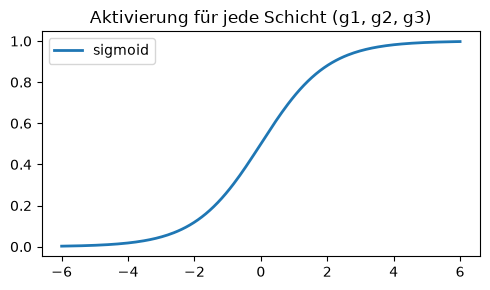

In [ ]:
z = torch.linspace(-6, 6, 200)
s = torch.sigmoid(z)

plt.figure(figsize=(5, 3))
plt.plot(z, s, lw=2, label="sigmoid")
plt.legend()
plt.title("Aktivierung für jede Schicht (g1, g2, g3)")
plt.tight_layout()
plt.show()

---
## Teil 2 — Spielzeugdatensatz (dasselbe Zwei-Kreise-Problem)

Gleiche Überlegung wie in Lesson 3b: eine einzige versteckte Schicht löst XOR problemlos, also verwenden wir zwei konzentrische Kreise, um die *zweite* versteckte Schicht wirklich zu fordern — nicht linear trennbar, und profitiert von zusätzlicher Tiefe.

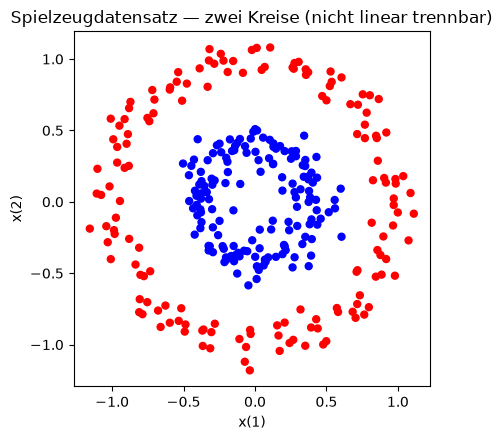

In [ ]:
from sklearn.datasets import make_circles

X_np, y_np = make_circles(n_samples=300, noise=0.08, factor=0.4, random_state=42)

X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np.reshape(-1, 1), dtype=torch.float32)

plt.figure(figsize=(4.5, 4.5))
colors = ["red" if yi == 0 else "blue" for yi in y_np]
plt.scatter(X_np[:, 0], X_np[:, 1], c=colors, s=25, zorder=3)
plt.xlabel("x(1)")
plt.ylabel("x(2)")
plt.title("Spielzeugdatensatz — zwei Kreise (nicht linear trennbar)")
plt.tight_layout()
plt.show()

---
## Teil 3 — Das Netz mit `nn.Module` definieren

Das ist das PyTorch-Äquivalent der `ThreeLayerNet`-Klasse aus Lesson 3b. Statt `W1, b1, W2, b2, W3, b3` als rohe NumPy-Arrays zu speichern und `forward`/`backward` von Hand zu schreiben, beschreiben wir die Architektur einmalig mit `nn.Sequential` — jedes `nn.Linear` hält bereits seine eigene Gewichtsmatrix und seinen Bias-Vektor, und die `nn.Sigmoid()`-Schichten wenden genau wie zuvor $g_1, g_2, g_3$ an.

$$y = f_3(f_2(f_1(\mathbf{x})))$$

ist jetzt einfach drei `nn.Linear` + `nn.Sigmoid()`-Paare, gestapelt in einem `nn.Sequential`.

In [ ]:
class ThreeLayerNet(nn.Module):
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden1),
            nn.Sigmoid(),                      # f1 / g1
            nn.Linear(n_hidden1, n_hidden2),
            nn.Sigmoid(),                      # f2 / g2
            nn.Linear(n_hidden2, n_output),
            nn.Sigmoid(),                      # f3 / g3
        )

    def forward(self, x):
        return self.net(x)

net = ThreeLayerNet(n_input=2, n_hidden1=4, n_hidden2=4, n_output=1)
print(net)

ThreeLayerNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): Sigmoid()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): Sigmoid()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


---
## Teil 4 — Loss-Funktion und Optimizer

Lesson 3b hat Binary Cross-Entropy von Hand berechnet und die Update-Regeln `W -= lr * dW` für jede Schicht selbst hergeleitet. In PyTorch:

- `nn.BCELoss()` ist derselbe Binary-Cross-Entropy-Loss, bereits fertig implementiert
- `optim.SGD(net.parameters(), lr=...)` führt für *jeden* Parameter im Netz automatisch dasselbe `W -= lr * dW`-Update aus — `net.parameters()` kennt bereits alle sechs Gewicht-/Bias-Tensoren, weil sie in den `nn.Linear`-Schichten leben

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.SGD(net.parameters(), lr=1.0)
print("Loss-Funktion und Optimizer bereit")

Loss-Funktion und Optimizer bereit


---
## Teil 5 — Trainingsschleife

Die manuelle Version hatte zwei Schritte pro Epoche: `forward()` dann `backward()`. Die PyTorch-Version hat vier, aber keiner davon verlangt, dass wir einen einzigen Gradienten selbst herleiten:

1. `optimizer.zero_grad()` — Gradienten vom vorherigen Schritt löschen
2. `net(X)` — Vorwärtsdurchlauf
3. `loss.backward()` — Autograd berechnet *jeden* Gradienten über die Kettenregel
4. `optimizer.step()` — das `W -= lr * dW`-Update auf alle Parameter gleichzeitig anwenden

In [ ]:
epochs = 8000
history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = net(X)
    loss = criterion(y_pred, y)
    loss.backward()
    print("epoch: ", epoch, ", loss: ", loss)
    optimizer.step()
    history.append(loss.item())

with torch.no_grad():
    pred_labels = (net(X) > 0.5).float()
    accuracy = (pred_labels == y).float().mean().item()

print(f"Finaler Loss: {history[-1]:.4f}")
print(f"Finale Genauigkeit: {accuracy:.2%}")

epoch:  0 , loss:  tensor(0.7071, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  1 , loss:  tensor(0.6967, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  2 , loss:  tensor(0.6940, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  3 , loss:  tensor(0.6933, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  4 , loss:  tensor(0.6932, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  5 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  6 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  7 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  8 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  9 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  10 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  11 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  12 , loss:  tensor(0.6931, grad_fn=<BinaryCrossEntropyBackward0>)
epoch:  13 , loss:  tensor(0.6931, grad_fn=<Bina

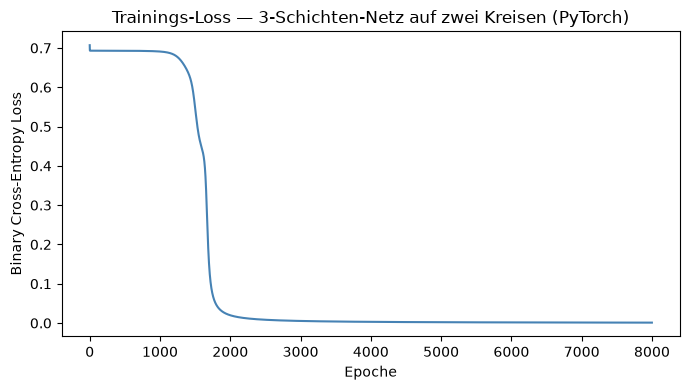

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history, color="steelblue")
plt.xlabel("Epoche")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Trainings-Loss — 3-Schichten-Netz auf zwei Kreisen (PyTorch)")
plt.tight_layout()
plt.show()

---
## Teil 6 — Entscheidungsgrenze visualisieren

Gleiche Idee wie in Lesson 3b: das Netz auf einem dichten Gitter auswerten und die Kontur zeichnen, wo die vorhergesagte Wahrscheinlichkeit 0.5 kreuzt. Das einzig PyTorch-spezifische Detail ist `torch.no_grad()` — wir machen hier nur Inferenz, also muss Autograd die Operationen nicht mitverfolgen.

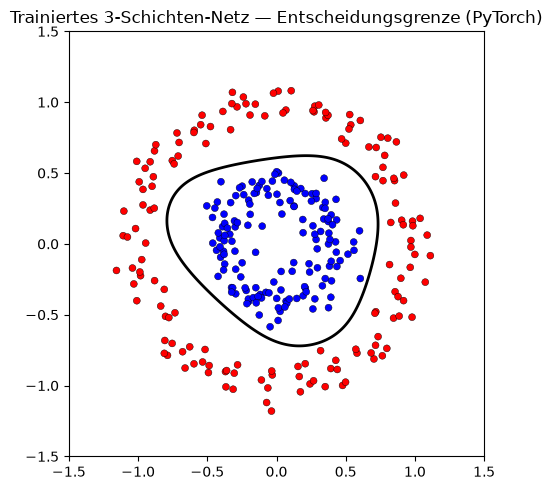

In [ ]:
def plot_boundary(net, title):
    xx, yy = torch.meshgrid(
        torch.linspace(-1.5, 1.5, 300),
        torch.linspace(-1.5, 1.5, 300),
        indexing="xy",
    )
    grid = torch.stack([xx.ravel(), yy.ravel()], dim=1)

    with torch.no_grad():
        Z = net(grid).reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    plt.contour(xx, yy, Z, levels=[0.5], colors="black", linewidths=2)
    colors = ["red" if yi == 0 else "blue" for yi in y_np]
    plt.scatter(X_np[:, 0], X_np[:, 1], c=colors, s=25, zorder=3, edgecolors="k", linewidths=0.3)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_boundary(net, "Trainiertes 3-Schichten-Netz — Entscheidungsgrenze (PyTorch)")

---
## Übungen

1. Entferne die zweite versteckte Schicht (zurück zu einem einzigen `Linear(2,4) → Sigmoid → Linear(4,1) → Sigmoid` wie in Lesson 3). Kann es das Zwei-Kreise-Problem immer noch genauso gut lösen?
2. Ändere `n_hidden1` und `n_hidden2` von 4 auf 2. Konvergiert das Netz noch?
3. Tausche `nn.Sigmoid()` in den versteckten Schichten gegen `nn.ReLU()` aus (behalte `nn.Sigmoid()` in der Ausgabeschicht für Wahrscheinlichkeiten bei). Ändert sich Trainingsgeschwindigkeit oder Stabilität?
4. Ersetze `optim.SGD` durch `optim.Adam(net.parameters(), lr=0.05)`. Konvergiert es schneller oder langsamer als reines SGD mit `lr=1.0`?
5. Probiere `make_moons` statt `make_circles` aus (beide aus `sklearn.datasets`). Löst dieselbe Architektur auch dieses Problem?

---
## Zusammenfassung

- `nn.Module` + `nn.Sequential` ersetzen die handgeschriebene `ThreeLayerNet`-Klasse aus Lesson 3b — jedes `nn.Linear` speichert bereits seine eigene Gewichtsmatrix und seinen Bias-Vektor
- `loss.backward()` ersetzt die komplette manuelle `backward()`-Methode — Autograd geht automatisch denselben Kettenregel-Pfad (Schicht 3 → Schicht 2 → Schicht 1)
- `optimizer.step()` ersetzt jede `W -= lr * dW`-Zeile — ein Aufruf aktualisiert *alle* Parameter im Netz
- Architektur, Mathematik und Ergebnisse sind identisch zu Lesson 3b — PyTorch entfernt nur die Buchhaltung